# WEEK 2 - Homework 2: Regression

> **Note**: this homework uses the pinned 2026 car fuel-efficiency release (`cohorts/2026/data/car_fuel_efficiency_2026.csv`).

Goal: create a regression model for predicting the car fuel efficiency (column `fuel_efficiency_mpg`).

## Dataset

Use only the following columns:

- `engine_displacement`
- `horsepower`
- `vehicle_weight`
- `model_year`
- `fuel_efficiency_mpg`

In [88]:
import numpy as np
import pandas as pd

df = pd.read_csv("../cohorts/2026/data/car_fuel_efficiency_2026.csv")

columns = [
    "engine_displacement",
    "horsepower",
    "vehicle_weight",
    "model_year",
    "fuel_efficiency_mpg",
]
df = df[columns]
df.head()

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,2180,243.0,3870,2006,31.9
1,2390,272.0,4210,2008,31.3
2,2320,267.0,4240,1996,27.5
3,2130,258.0,4490,1989,28.5
4,2580,304.0,4510,1994,31.0


In [89]:
import matplotlib.pyplot as plt
import seaborn as sns

## EDA

Look at the `fuel_efficiency_mpg` variable. Does it have a long tail?

<Axes: xlabel='fuel_efficiency_mpg', ylabel='Count'>

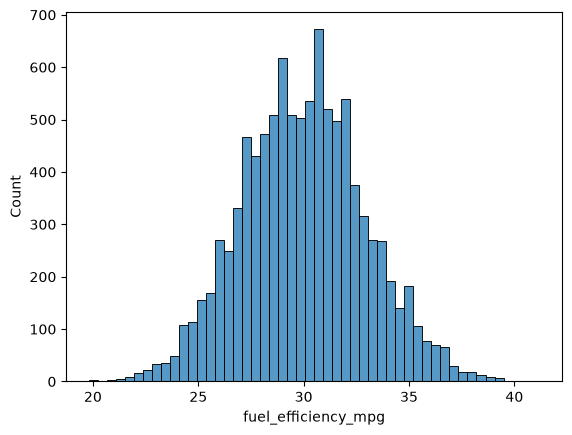

In [90]:
sns.histplot(df["fuel_efficiency_mpg"], bins=50)

## Question 1

There's one column with missing values. What is it?

- `'engine_displacement'`
- `'horsepower'`
- `'vehicle_weight'`
- `'model_year'`

In [91]:
for col in df.columns:
  if df[col].isnull().sum() > 0:
    print(f"{col} has {df[col].isnull().sum()} missing values")


df.isnull().sum()

horsepower has 877 missing values


engine_displacement      0
horsepower             877
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64

## Question 2

What's the median (50% percentile) for variable `'horsepower'`?

- 204
- 254
- 304
- 354

In [92]:
df["horsepower"].median()


np.float64(254.0)

## Prepare and split the dataset

Shuffle the filtered dataset and create the split exactly as in the lecture. For Q5, repeat this block with each listed seed. For Q6, use seed `9`.

In [93]:
n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

np.random.seed(42)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train + n_val]]
df_test = df.iloc[idx[n_train + n_val:]]

## Question 3

- We need to deal with missing values for the column from Q1.
- We have two options: fill it with 0 or with the mean of this variable.
- Try both options. For each, train a linear regression model without regularization using the code from the lessons.
- For computing the mean, use the training only!
- Use the validation dataset to evaluate the models and compare the RMSE of each option.
- Round the RMSE scores to 3 decimal digits using `round(score, 3)`.
- Which option gives better RMSE?

Options:

- With 0
- With mean
- Both are equally good

In [94]:
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]

def rmse(y, y_pred):
    se = (y - y_pred) ** 2
    mse = se.mean()
    return np.sqrt(mse)


In [95]:
# 1) Rellenar los NaN.
#    La media se calcula SOLO con train y se usa también para validation
#    (validation simula datos "nuevos": no podemos mirar su media).
mean_hp = df_train["horsepower"].mean()

df_train_zero = df_train.fillna(0)
df_train_mean = df_train.fillna(mean_hp)

df_val_zero = df_val.fillna(0)
df_val_mean = df_val.fillna(mean_hp)  # media de TRAIN, no de validation

# 2) Separar features (X) y target (y) para train y validation
x_train_zero = df_train_zero.drop("fuel_efficiency_mpg", axis=1).values
x_train_mean = df_train_mean.drop("fuel_efficiency_mpg", axis=1).values
y_train_zero = df_train_zero["fuel_efficiency_mpg"].values
y_train_mean = df_train_mean["fuel_efficiency_mpg"].values

x_val_zero = df_val_zero.drop("fuel_efficiency_mpg", axis=1).values
x_val_mean = df_val_mean.drop("fuel_efficiency_mpg", axis=1).values
y_val_zero = df_val_zero["fuel_efficiency_mpg"].values
y_val_mean = df_val_mean["fuel_efficiency_mpg"].values

# 3) ENTRENAR con train: aquí se aprenden los pesos w0 y w
w0_zero, w_zero = train_linear_regression(x_train_zero, y_train_zero)
w0_mean, w_mean = train_linear_regression(x_train_mean, y_train_mean)

# 4) PREDECIR con validation: usamos los pesos de train sobre x_val.
#    Así y_pred tiene el mismo tamaño que y_val (2000) y rmse() funciona.
y_pred_zero = w0_zero + x_val_zero.dot(w_zero)
y_pred_mean = w0_mean + x_val_mean.dot(w_mean)


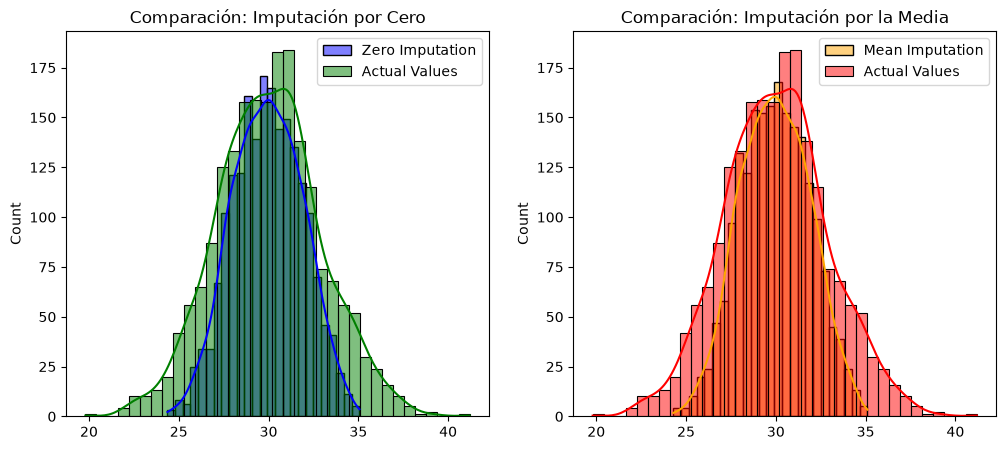

In [96]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(y_pred_zero, color="blue", label="Zero Imputation", kde=True, ax=axes[0])
sns.histplot(y_val_zero, color="green", label="Actual Values", kde=True, ax=axes[0])
axes[0].set_title("Comparación: Imputación por Cero")
axes[0].legend() 

sns.histplot(y_pred_mean, color="orange", label="Mean Imputation", kde=True, ax=axes[1])
sns.histplot(y_val_mean, color="red", label="Actual Values", kde=True, ax=axes[1])
axes[1].set_title("Comparación: Imputación por la Media")
axes[1].legend()

In [97]:
rmse_zero = rmse(y_val_zero, y_pred_zero)
rmse_mean = rmse(y_val_mean, y_pred_mean)

print(f"RMSE (Imputación por Cero): {round(rmse_zero, 3)}")
print(f"RMSE (Imputación por la Media): {round(rmse_mean, 3)}")

RMSE (Imputación por Cero): 2.205
RMSE (Imputación por la Media): 2.202


## Question 4

- Now let's train a regularized linear regression.
- For this question, fill the NAs with 0.
- Try different values of `r` from this list: `[0, 0.01, 0.1, 1, 5, 10, 100]`.
- Use RMSE to evaluate the model on the validation dataset.
- Round the RMSE scores to 4 decimal digits.
- Which `r` gives the best RMSE?

If multiple options give the same best RMSE, select the smallest `r`.

Options:

- 0
- 0.01
- 0.1
- 1
- 5
- 10
- 100

In [98]:
def train_linear_regression_reg(X, y, r=0.001):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX = XTX + r * np.eye(XTX.shape[0])

    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]


In [99]:
def prepare_data(df_, fill_value):
  df_ = df_.fillna(fill_value)

  X = df_.drop("fuel_efficiency_mpg", axis=1).values
  y = df_["fuel_efficiency_mpg"].values

  return X, y

In [100]:
reg = [0, 0.01, 0.1, 1, 5, 10, 100]

X_train, y_train = prepare_data(df_train, fill_value=0)
X_val, y_val = prepare_data(df_val, fill_value=0)

for r in reg:
  w0,w = train_linear_regression_reg(X_train, y_train, r=r)

  y_pred = w0 + X_val.dot(w)

  rmse_val = rmse(y_val, y_pred)
  print(f"RMSE (Regularización {r}): {round(rmse_val, 4)}")


RMSE (Regularización 0): 2.2053
RMSE (Regularización 0.01): 2.2058
RMSE (Regularización 0.1): 2.2241
RMSE (Regularización 1): 2.3492
RMSE (Regularización 5): 2.4094
RMSE (Regularización 10): 2.4195
RMSE (Regularización 100): 2.4292


## Question 5

- We used seed 42 for splitting the data. Let's find out how selecting the seed influences our score.
- Try different seed values: `[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]`.
- For each seed, do the train/validation/test split with 60%/20%/20% distribution.
- Fill the missing values with 0 and train a model without regularization.
- For each seed, evaluate the model on the validation dataset and collect the RMSE scores.
- What's the standard deviation of all the scores? Use `np.std`.
- Round the result to 3 decimal digits (`round(std, 3)`)

What's the value of std?

- 0.006
- 0.016
- 0.029
- 0.036

In [101]:
seeds = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
rmse_list = []

for seed in seeds:

  n_Q5 = len(df)
  n_val_Q5 = int(n_Q5 * 0.2)
  n_test_Q5 = int(n_Q5 * 0.2)
  n_train_Q5 = n_Q5 - n_val_Q5 - n_test_Q5

  np.random.seed(seed)
  idx_Q5 = np.arange(n_Q5)
  np.random.shuffle(idx_Q5)

  df_train_Q5 = df.iloc[idx_Q5[:n_train_Q5]]
  df_val_Q5 = df.iloc[idx_Q5[n_train_Q5:n_train_Q5 + n_val_Q5]]
  df_test_Q5 = df.iloc[idx_Q5[n_train_Q5 + n_val_Q5:]]

  X_train_Q5, y_train_Q5 = prepare_data(df_train_Q5, fill_value=0)
  X_val_Q5, y_val_Q5 = prepare_data(df_val_Q5, fill_value=0)

  w0_Q5,w_Q5 = train_linear_regression(X_train_Q5, y_train_Q5)

  y_pred_Q5 = w0_Q5 + X_val_Q5.dot(w_Q5)
  rmse_Q5 = rmse(y_val_Q5, y_pred_Q5)
  print(f"Seed {seed}: RMSE = {round(rmse_Q5, 3)}")
  rmse_list.append(rmse_Q5)

print(f"Desviación estándar de RMSE: {round(np.std(rmse_list), 3)}")


Seed 0: RMSE = 2.239
Seed 1: RMSE = 2.202
Seed 2: RMSE = 2.163
Seed 3: RMSE = 2.204
Seed 4: RMSE = 2.202
Seed 5: RMSE = 2.246
Seed 6: RMSE = 2.27
Seed 7: RMSE = 2.191
Seed 8: RMSE = 2.217
Seed 9: RMSE = 2.207
Desviación estándar de RMSE: 0.029


## Question 6

- Split the dataset like previously, use seed 9.
- Combine train and validation datasets.
- Fill the missing values with 0 and train a model with `r=0.001`.
- What's the RMSE on the test dataset?

Options:

- 0.236
- 2.236
- 22.10
- 221.0

In [102]:
n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

np.random.seed(9)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train + n_val]]
df_test = df.iloc[idx[n_train + n_val:]]

df_full_train = pd.concat([df_train, df_val])

X_full_train, y_full_train = prepare_data(df_full_train, fill_value=0)
X_test, y_test = prepare_data(df_test, fill_value=0)

w0,w = train_linear_regression_reg(X_full_train, y_full_train, r=0.001)

y_pred_test = w0 + X_test.dot(w)
rmse_test = rmse(y_test, y_pred_test)
print(f"RMSE on test set: {round(rmse_test, 3)}")


RMSE on test set: 2.236


## Submit the results

https://courses.datatalks.club/ml-zoomcamp-2026/homework/hw02